In [1]:
import numpy as np
import astropy.io.fits as fits
from astropy.table import Table
import matplotlib.pyplot as plt
import matplotlib 


# Spimodfit response (RMF)
Here Im plotting the response file created by spimodfit. The file is ment to be used with three ml to do the fitting to the model provided later. 
matches with what jochen has sent me. Between 100 and 600 keV are around 20 bins

More Energies then channels. 

Ich denke, wenn wir eine bessere Energieauflsung als in der response haben ist das perse nicht so schlimm. Natürlich wäre die bessere Auflsung in der Response gut aber wir können was das forward folding angeht trotzdem die Response verwenden. 
Genau das wird in der smf response auch gemacht. die Energieauflösung ist die von den energiebins die wir als Input verwendet haben und dann soweit erweitert, dass es auf die Channels passt.

Filename: /home/tguethle/cookbook/SPI_cookbook/examples/automated_Crab/fit_Crab_band_fit_727_smf_SE/spectral_response.rmf.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      18   ()      
  1  GROUPING      1 BinTableHDU     50   2R x 9C   [8A, 32A, 1J, 1J, 256A, 3A, 1I, 1D, 1D]   
  2  MATRIX        1 BinTableHDU     46   200R x 6C   [1E, 1E, 1I, 1I, 1I, 1PE(40)]   
  3  EBOUNDS       1 BinTableHDU     39   40R x 3C   [1J, 1E, 1E]   


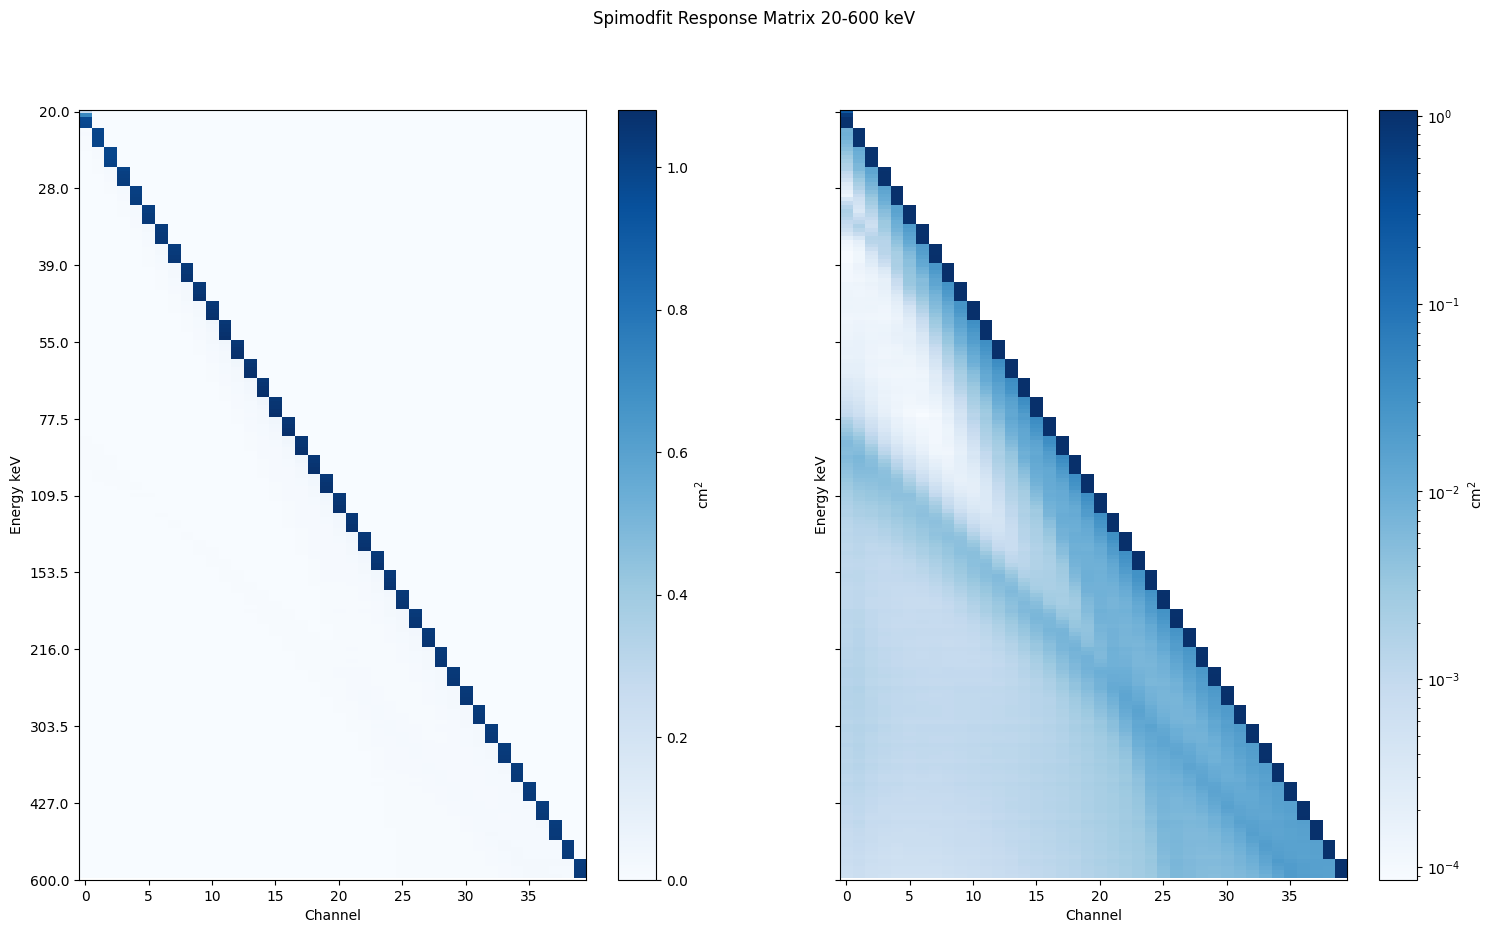

In [ ]:
smf_response = "/home/tguethle/cookbook/SPI_cookbook/examples/automated_Crab/fit_Crab_band_fit_727_smf_SE/spectral_response.rmf.fits"

with fits.open(smf_response) as hdul:
    hdul.info()
    data = hdul[2].data
    t = Table(data)


energy_low = np.array(t["ENERG_LO"])
energy_low = np.append(energy_low, t["ENERG_HI"][-1])
matrix = t["MATRIX"]
len(matrix[-1])

response_matrix = np.zeros((len(matrix), len(matrix[-1])))
for i, m in enumerate(matrix):
    m_array = np.zeros(len(matrix[-1]))  # Create an array of zeros with length 41
    m_array[:len(m)] = m  # Copy the values of m into m_array
    response_matrix[i] = m_array  # Assign m_array to the response matrix

fig, ax = plt.subplots(1, 2, figsize=(18, 10), sharey=True)

im = ax[0].imshow(response_matrix, origin='upper', cmap='Blues', aspect="auto", interpolation='none')

plt.colorbar(im, label='cm$^2$')
ax[0].set_xlabel("Channel")
ax[0].set_ylabel("Energy keV")
ax[0].set_yticks(np.linspace(0, len(matrix), 11),  energy_low[::int(np.floor(len(energy_low)/10))])

response_matrix[response_matrix < 1e-7] = np.nan
ax[1].imshow(np.zeros_like(response_matrix), origin='upper', cmap='Greys', aspect='auto', interpolation='none')
im = ax[1].imshow(response_matrix, origin='upper', cmap='Blues', aspect='auto', norm=matplotlib.colors.LogNorm())
plt.colorbar(im, label='cm$^2$')
ax[1].set_xlabel("Channel")
ax[1].set_ylabel("Energy keV")
ax[1].set_yticks(np.linspace(0, len(matrix), 11),  energy_low[::int(np.floor(len(energy_low)/10))])

fig.suptitle("Spimodfit Response Matrix 20-600 keV")
fig.savefig("spimodfit_response_matrix.pdf")
# Note: some pdf viewers will misinterpres the interpolation and interpolate anyways... stupid

This below is the base version of the response file. It contains a mapping from every channel to the true energies. the mapping of course only goes in one direction. and naturally the channels are only map to energies below their own max energy.

Here the number of channels is equal to the number of energies. for upper rmf this is not the case.

I belive the response that is used is the base case but interpolated to fit the energie bins. the base case is adjusted to the energy bins form the spiselect input file... for each bin, five energy subbins are used.

In [33]:
base_smf_response = "/home/tguethle/Desktop/spi_rmf_grp_0002.fits"

with fits.open(base_smf_response) as hdul:
    hdul.info()

    rmf = hdul[2].data
    rmf = Table(rmf)

rmf

Filename: /home/tguethle/Desktop/spi_rmf_grp_0002.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      17   ()      
  1  GROUPING      1 BinTableHDU     59   2R x 9C   [8A, 32A, 1J, 1J, 256A, 3A, 1I, 1D, 1D]   
  2  SPI.-RMF.-RSP    1 BinTableHDU     46   100R x 6C   [1E, 1E, 1I, 1I, 1I, 1PE(100)]   
  3  SPI.-EBDS-MOD    1 BinTableHDU     42   100R x 3C   [1J, 1E, 1E]   


ENERG_LO,ENERG_HI,N_GRP,F_CHAN,N_CHAN,MATRIX
float32,float32,int16,int16,int16,object
20.000002,21.234917,1,0,1,[0.9703555]
21.234917,22.54609,1,0,2,[0.00789636 0.99147844]
22.54609,23.938213,1,0,3,[0.00400642 0.00859786 0.9861112 ]
23.938213,25.416304,1,0,4,[0.00176234 0.00425016 0.0093054 0.9837711 ]
25.416304,26.985659,1,0,5,[4.3828090e-04 2.1404438e-03 4.3488024e-03 1.0529536e-02 1.0094259e+00]
26.985659,28.651909,1,0,6,[9.7915996e-05 6.4205495e-04 2.3483522e-03 4.7137174e-03 1.1864823e-02\n 1.0157667e+00]
28.651909,30.421051,1,0,7,[8.4989915e-05 1.9683555e-04 7.9668500e-04 2.5792420e-03 4.9923165e-03\n 1.3206226e-02 1.0107595e+00]
30.421051,32.29943,1,0,8,[2.6711756e-03 9.4252428e-05 2.6134783e-04 1.1142986e-03 2.9037884e-03\n 5.6097489e-03 1.4863246e-02 1.0214002e+00]
32.29943,34.29378,1,0,9,[1.5900716e-04 2.3902080e-03 1.5297015e-04 3.5494755e-04 1.4640881e-03\n 3.2589410e-03 6.2284502e-03 1.6705887e-02 1.0297692e+00]


In [36]:
t[0:20]

ENERG_LO,ENERG_HI,N_GRP,F_CHAN,N_CHAN,MATRIX
float32,float32,int16,int16,int16,object
20.0,20.3,1,0,1,[0.23841916]
20.3,20.6,1,0,1,[0.717062]
20.6,20.9,1,0,1,[0.97290915]
20.9,21.2,1,0,1,[0.97898334]
21.2,21.5,1,0,1,[0.98582083]
21.5,21.9,1,0,2,[0.00809874 0.9884638 ]
21.9,22.3,1,0,2,[0.00881532 0.9929543 ]
22.3,22.7,1,0,2,[0.0077143 0.9935077]
22.7,23.1,1,0,2,[0.00648629 0.99397343]
